# 💧 AgroSat — Regressão de Risco Hídrico
### Global Solution 2026/1 — FIAP | AI & Chatbot

| Integrante | RM | Turma |
|---|---|---|
| Gustavo Rodrigues Siciliano | RM568419 | 1TDS Agosto |
| Gustavo de Jesus Silva | RM567926 | 1TDS Agosto |
| Samuel Keniti Kina de Lima | RM567614 | 1TDS Agosto |

**GitHub:** https://github.com/GustavoSiciliano/Global-Solution-2026

---

## Sobre este notebook

Modelo 2 do pipeline AgroSat: prevê o percentual de risco hídrico (0% a 100%) usando dados satelitais da NASA.

- 🟢 **0% a 20%** — Risco BAIXO
- 🟡 **20% a 40%** — Risco MÉDIO
- 🟠 **40% a 70%** — Risco ALTO
- 🔴 **70% a 100%** — Risco CRÍTICO

**Algoritmo:** Random Forest Regressor | **Dataset:** 300 registros, 10 regiões agrícolas brasileiras

---
## 1. Imports e Carregamento dos Dados

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
import os
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Bibliotecas carregadas!')

Bibliotecas carregadas!


In [2]:
# Resolve caminho relativo ao notebook independente de onde o Jupyter foi aberto
BASE_DIR = Path('__file__').resolve().parent if Path('__file__').exists() else Path().resolve()
while not (BASE_DIR / 'data').exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent

df = pd.read_csv(BASE_DIR / 'data' / 'agrosat_dataset.csv')
print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
print(f'Nulos: {df.isnull().sum().sum()}')
df.head(10)

Shape: (300, 9)
Colunas: ['regiao', 'ndvi', 'temperatura', 'precipitacao', 'umidade', 'dias_sem_chuva', 'radiacao_solar', 'status_vegetacao', 'risco_hidrico']
Nulos: 0


,regiao,ndvi,temperatura,precipitacao,umidade,dias_sem_chuva,radiacao_solar,status_vegetacao,risco_hidrico
0,Passo Fundo/RS,-0.0285,38.46,1.79,18.92,42,23.41,CRITICO,95.92
1,Uberlândia/MG,0.3164,33.05,14.20,30.02,17,19.28,EM_ESTRESSE,40.80
2,Palmas/TO,0.8141,19.67,28.15,72.82,5,10.91,SAUDAVEL,14.75
3,Barreiras/BA,0.3135,32.25,4.22,31.95,9,24.60,EM_ESTRESSE,49.03
4,Santarém/PA,0.8395,23.28,20.49,77.33,2,19.09,SAUDAVEL,7.44
5,Lucas do Rio Verde/MT,0.3603,31.97,2.41,55.27,17,24.58,EM_ESTRESSE,61.91
6,Uberlândia/MG,0.4510,34.73,12.98,52.42,10,22.11,EM_ESTRESSE,64.43
7,Palmas/TO,0.6578,18.19,34.05,73.82,2,11.99,SAUDAVEL,19.52
8,Rio Verde/GO,0.1539,39.40,2.55,18.99,20,23.44,CRITICO,74.84
9,Rondonópolis/MT,0.3797,31.93,6.98,59.15,8,23.33,EM_ESTRESSE,51.27


In [3]:
print('Estatísticas do risco_hidrico:')
print(df['risco_hidrico'].describe().round(2))

Estatísticas do risco_hidrico:
count    300.00
mean      45.82
std       30.15
min        0.00
25%       16.83
50%       42.70
75%       72.11
max      100.00
Name: risco_hidrico, dtype: float64


---
## 2. Análise Exploratória dos Dados (EDA)

> Entender a distribuição do risco hídrico e como cada variável satelital se relaciona com ele.

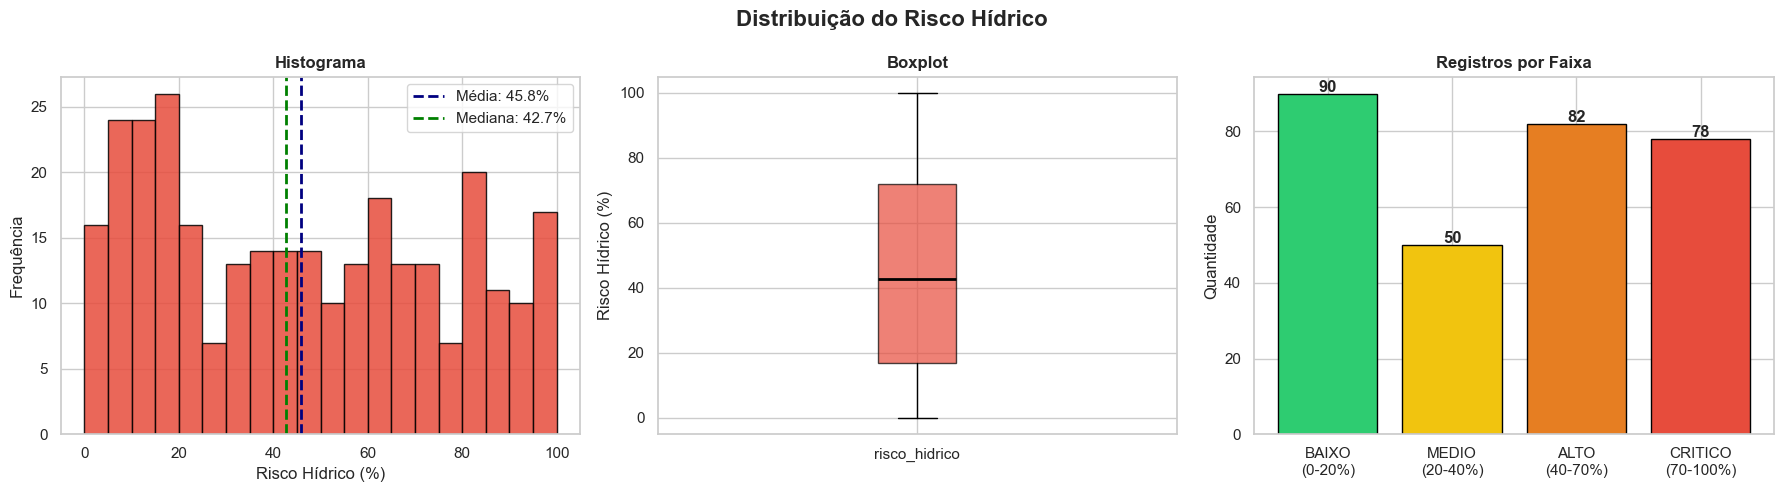

In [4]:
# Distribuição do risco hídrico — histograma, boxplot e faixas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribuição do Risco Hídrico', fontsize=16, fontweight='bold')

axes[0].hist(df['risco_hidrico'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.85)
axes[0].axvline(df['risco_hidrico'].mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Média: {df["risco_hidrico"].mean():.1f}%')
axes[0].axvline(df['risco_hidrico'].median(), color='green', linestyle='--', linewidth=2,
                label=f'Mediana: {df["risco_hidrico"].median():.1f}%')
axes[0].set_title('Histograma', fontweight='bold')
axes[0].set_xlabel('Risco Hídrico (%)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

axes[1].boxplot(df['risco_hidrico'], patch_artist=True,
                boxprops=dict(facecolor='#e74c3c', alpha=0.7),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Boxplot', fontweight='bold')
axes[1].set_ylabel('Risco Hídrico (%)')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['risco_hidrico'])

faixas = {'BAIXO\n(0-20%)': len(df[df['risco_hidrico'] < 20]),
          'MEDIO\n(20-40%)': len(df[(df['risco_hidrico'] >= 20) & (df['risco_hidrico'] < 40)]),
          'ALTO\n(40-70%)': len(df[(df['risco_hidrico'] >= 40) & (df['risco_hidrico'] < 70)]),
          'CRITICO\n(70-100%)': len(df[df['risco_hidrico'] >= 70])}
cores_f = ['#2ecc71','#f1c40f','#e67e22','#e74c3c']
bars = axes[2].bar(faixas.keys(), faixas.values(), color=cores_f, edgecolor='black')
for bar, v in zip(bars, faixas.values()):
    axes[2].text(bar.get_x()+bar.get_width()/2, v+0.5, str(v), ha='center', fontweight='bold')
axes[2].set_title('Registros por Faixa', fontweight='bold')
axes[2].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

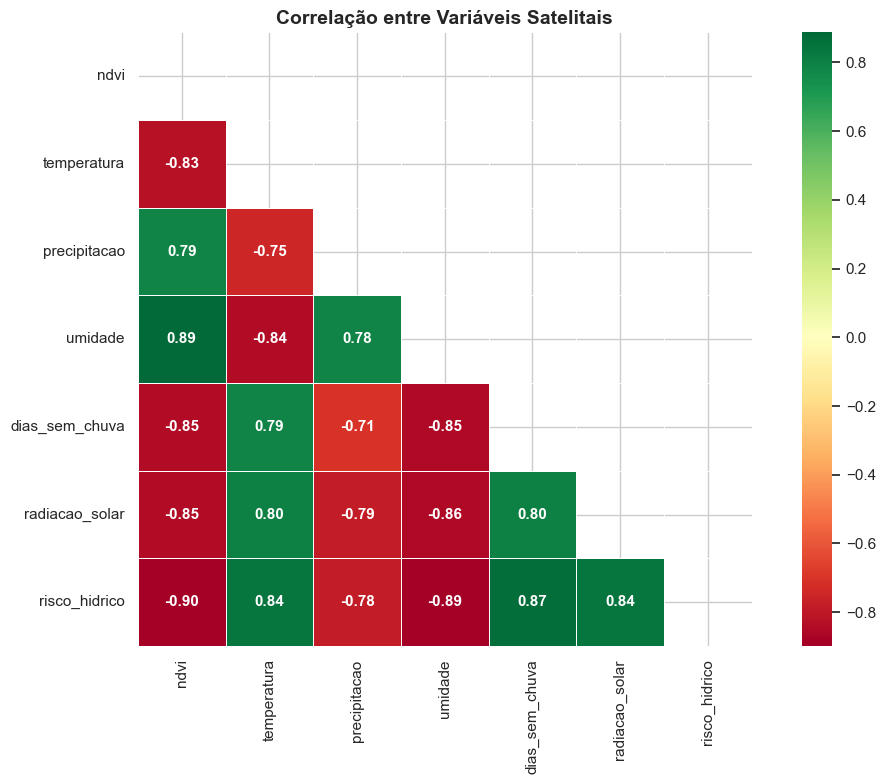

Variáveis mais correlacionadas com risco_hidrico: ndvi (-), dias_sem_chuva (+), umidade (-)


In [5]:
# Heatmap de correlação
fig, ax = plt.subplots(figsize=(11, 8))
features_num = ['ndvi','temperatura','precipitacao','umidade','dias_sem_chuva','radiacao_solar','risco_hidrico']
corr = df[features_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5, mask=mask, ax=ax,
            annot_kws={'size': 11, 'weight': 'bold'})
ax.set_title('Correlação entre Variáveis Satelitais', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('Variáveis mais correlacionadas com risco_hidrico: ndvi (-), dias_sem_chuva (+), umidade (-)')

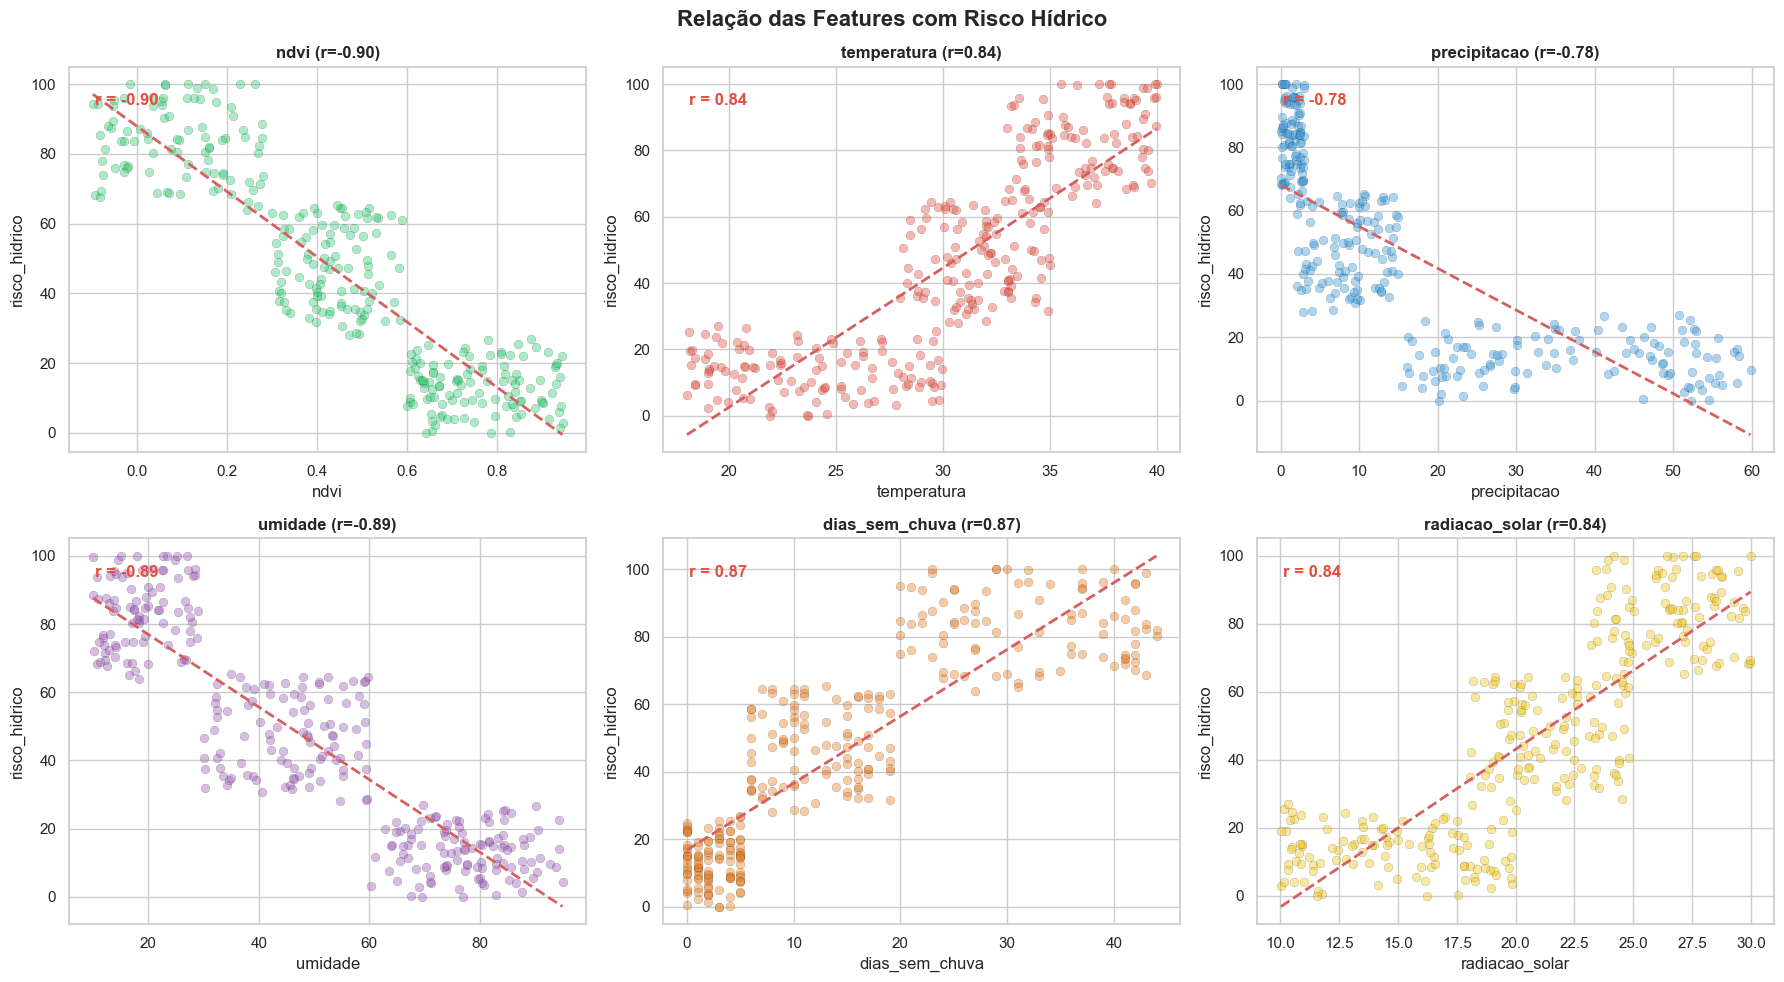

In [6]:
# Scatter plots com linha de tendência e coeficiente r
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Relação das Features com Risco Hídrico', fontsize=16, fontweight='bold')
axes = axes.flatten()
features_scatter = ['ndvi','temperatura','precipitacao','umidade','dias_sem_chuva','radiacao_solar']
cores_s = ['#2ecc71','#e74c3c','#3498db','#9b59b6','#e67e22','#f1c40f']
for ax, var, cor in zip(axes, features_scatter, cores_s):
    ax.scatter(df[var], df['risco_hidrico'], alpha=0.4, color=cor, edgecolors='black', linewidth=0.2, s=40)
    z = np.polyfit(df[var], df['risco_hidrico'], 1)
    p = np.poly1d(z)
    ax.plot(sorted(df[var]), p(sorted(df[var])), 'r--', linewidth=2)
    corr_val = df[var].corr(df['risco_hidrico'])
    ax.set_xlabel(var)
    ax.set_ylabel('risco_hidrico')
    ax.set_title(f'{var} (r={corr_val:.2f})', fontweight='bold')
    ax.annotate(f'r = {corr_val:.2f}', xy=(0.05, 0.90), xycoords='axes fraction',
                fontsize=12, fontweight='bold',
                color='#e74c3c' if abs(corr_val) > 0.5 else '#f39c12')
plt.tight_layout()
plt.show()

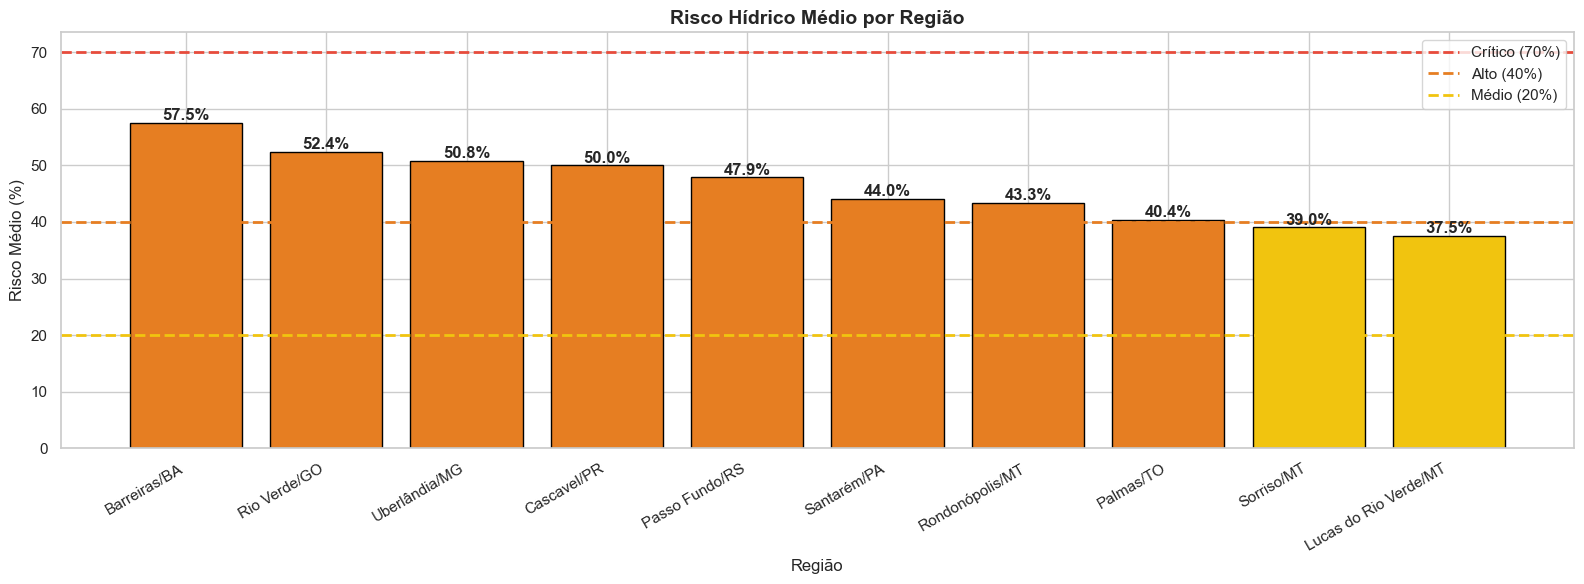

In [7]:
# Risco médio por região
fig, ax = plt.subplots(figsize=(16, 6))
risco_regiao = df.groupby('regiao')['risco_hidrico'].mean().sort_values(ascending=False)
cores_r = ['#e74c3c' if v >= 70 else '#e67e22' if v >= 40 else '#f1c40f' if v >= 20 else '#2ecc71'
           for v in risco_regiao.values]
bars = ax.bar(risco_regiao.index, risco_regiao.values, color=cores_r, edgecolor='black')
ax.axhline(70, color='#e74c3c', linestyle='--', linewidth=2, label='Crítico (70%)')
ax.axhline(40, color='#e67e22', linestyle='--', linewidth=2, label='Alto (40%)')
ax.axhline(20, color='#f1c40f', linestyle='--', linewidth=2, label='Médio (20%)')
for bar, v in zip(bars, risco_regiao.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_title('Risco Hídrico Médio por Região', fontsize=14, fontweight='bold')
ax.set_xlabel('Região')
ax.set_ylabel('Risco Médio (%)')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Pré-processamento

In [8]:
FEATURES = ['ndvi','temperatura','precipitacao','umidade','dias_sem_chuva','radiacao_solar']
X = df[FEATURES]
y = df['risco_hidrico']
print(f'Features: {FEATURES}')
print(f'Target: min={y.min():.2f}% | max={y.max():.2f}% | média={y.mean():.2f}%')

Features: ['ndvi', 'temperatura', 'precipitacao', 'umidade', 'dias_sem_chuva', 'radiacao_solar']
Target: min=0.00% | max=100.00% | média=45.82%


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Treino: {len(X_train)} | Teste: {len(X_test)}')

Treino: 240 | Teste: 60


---
## 4. Treinamento

> Random Forest Regressor: média das previsões de 100 árvores para estimar o risco hídrico contínuo.

In [10]:
reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
reg.fit(X_train, y_train)
print(f'Modelo treinado! Árvores: {reg.n_estimators}')

Modelo treinado! Árvores: 100


---
## 5. Avaliação de Desempenho

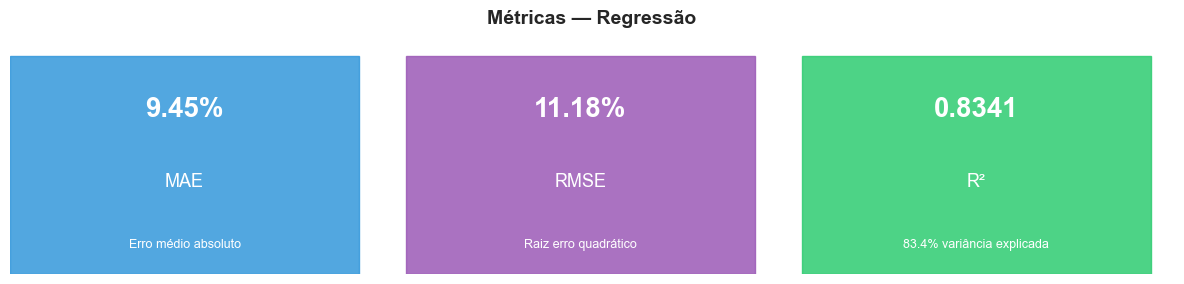

In [11]:
y_pred = reg.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
metricas = [
    ('MAE', f'{mae:.2f}%', 'Erro médio absoluto', '#3498db'),
    ('RMSE', f'{rmse:.2f}%', 'Raiz erro quadrático', '#9b59b6'),
    ('R²', f'{r2:.4f}', f'{r2*100:.1f}% variância explicada',
     '#2ecc71' if r2 >= 0.8 else '#f39c12')
]
for i, (nome, valor, desc, cor) in enumerate(metricas):
    x = i * 0.34
    ax.add_patch(plt.Rectangle((x, 0), 0.30, 0.9, color=cor, alpha=0.85, transform=ax.transAxes))
    ax.text(x+0.15, 0.68, valor, ha='center', va='center',
            fontsize=20, fontweight='bold', color='white', transform=ax.transAxes)
    ax.text(x+0.15, 0.38, nome, ha='center', va='center',
            fontsize=13, color='white', transform=ax.transAxes)
    ax.text(x+0.15, 0.12, desc, ha='center', va='center',
            fontsize=9, color='white', transform=ax.transAxes)
ax.set_title('Métricas — Regressão', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

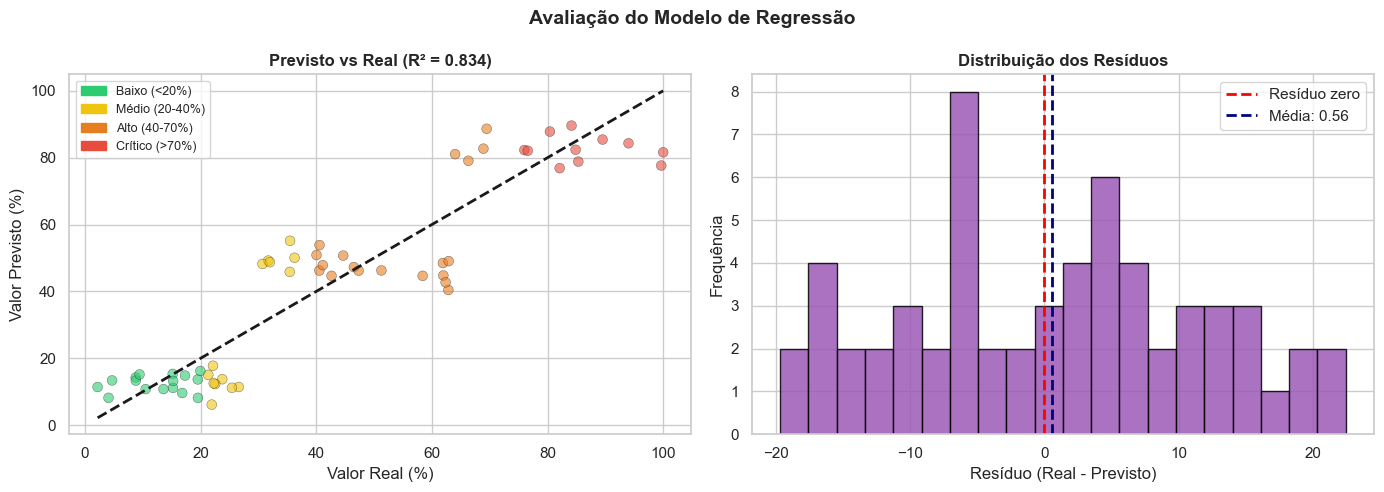

Resíduos centrados em zero indicam que o modelo não tem viés sistemático.


In [12]:
# Previsto vs Real + Resíduos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Avaliação do Modelo de Regressão', fontsize=14, fontweight='bold')

cores_pts = ['#e74c3c' if v >= 70 else '#e67e22' if v >= 40 else '#f1c40f' if v >= 20 else '#2ecc71'
             for v in y_test]
axes[0].scatter(y_test, y_pred, alpha=0.6, color=cores_pts, edgecolors='black', linewidth=0.3, s=50)
min_v, max_v = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
axes[0].plot([min_v, max_v], [min_v, max_v], 'k--', linewidth=2, label='Previsão perfeita')
axes[0].set_xlabel('Valor Real (%)')
axes[0].set_ylabel('Valor Previsto (%)')
axes[0].set_title(f'Previsto vs Real (R² = {r2:.3f})', fontweight='bold')
patches = [
    mpatches.Patch(color='#2ecc71', label='Baixo (<20%)'),
    mpatches.Patch(color='#f1c40f', label='Médio (20-40%)'),
    mpatches.Patch(color='#e67e22', label='Alto (40-70%)'),
    mpatches.Patch(color='#e74c3c', label='Crítico (>70%)')
]
axes[0].legend(handles=patches, fontsize=9)

residuos = y_test.values - y_pred
axes[1].hist(residuos, bins=20, color='#9b59b6', edgecolor='black', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Resíduo zero')
axes[1].axvline(residuos.mean(), color='navy', linestyle='--', linewidth=2,
                label=f'Média: {residuos.mean():.2f}')
axes[1].set_xlabel('Resíduo (Real - Previsto)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.show()
print('Resíduos centrados em zero indicam que o modelo não tem viés sistemático.')

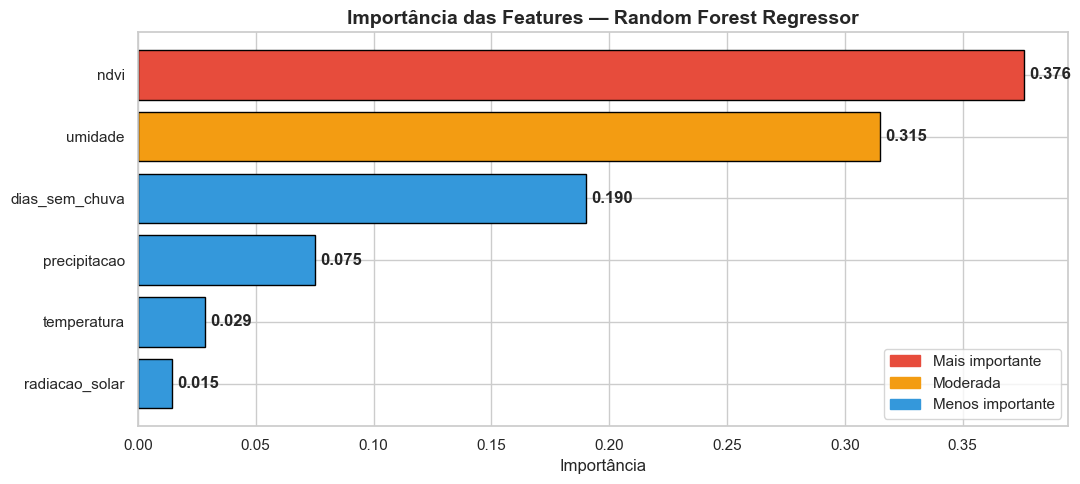

Feature mais importante: ndvi


In [13]:
# Feature importance
fig, ax = plt.subplots(figsize=(11, 5))
importances = pd.Series(reg.feature_importances_, index=FEATURES).sort_values()
cores_imp = ['#e74c3c' if v == importances.max() else
             '#f39c12' if v >= importances.quantile(0.66) else '#3498db'
             for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=cores_imp, edgecolor='black')
for bar, v in zip(bars, importances.values):
    ax.text(v+0.002, bar.get_y()+bar.get_height()/2, f'{v:.3f}', va='center', fontweight='bold')
ax.set_title('Importância das Features — Random Forest Regressor', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
patches = [
    mpatches.Patch(color='#e74c3c', label='Mais importante'),
    mpatches.Patch(color='#f39c12', label='Moderada'),
    mpatches.Patch(color='#3498db', label='Menos importante')
]
ax.legend(handles=patches)
plt.tight_layout()
plt.show()
print(f'Feature mais importante: {importances.idxmax()}')

In [14]:
# Testes manuais com 3 regiões reais
amostras = [
    {'regiao': 'Rondonópolis/MT', 'esperado': 'CRÍTICO',
     'ndvi': 0.21, 'temperatura': 35.8, 'precipitacao': 0.0,
     'umidade': 28.0, 'dias_sem_chuva': 30, 'radiacao_solar': 26.1},
    {'regiao': 'Cascavel/PR', 'esperado': 'BAIXO',
     'ndvi': 0.78, 'temperatura': 22.1, 'precipitacao': 35.0,
     'umidade': 80.0, 'dias_sem_chuva': 0, 'radiacao_solar': 15.3},
    {'regiao': 'Lucas do Rio Verde/MT', 'esperado': 'ALTO',
     'ndvi': 0.45, 'temperatura': 32.1, 'precipitacao': 0.0,
     'umidade': 42.0, 'dias_sem_chuva': 15, 'radiacao_solar': 24.8}
]
print('Testes manuais:\n')
for a in amostras:
    regiao = a.pop('regiao')
    esperado = a.pop('esperado')
    entrada = pd.DataFrame([a])
    risco = round(float(reg.predict(entrada)[0]), 2)
    risco = max(0.0, min(100.0, risco))
    nivel = 'CRITICO' if risco >= 70 else 'ALTO' if risco >= 40 else 'MEDIO' if risco >= 20 else 'BAIXO'
    print(f'  {regiao} → {risco:.1f}% | Nível: {nivel} | Esperado: {esperado}')

Testes manuais:

  Rondonópolis/MT → 79.1% | Nível: CRITICO | Esperado: CRÍTICO
  Cascavel/PR → 16.0% | Nível: BAIXO | Esperado: BAIXO
  Lucas do Rio Verde/MT → 54.4% | Nível: ALTO | Esperado: ALTO


In [15]:
os.makedirs(BASE_DIR / 'pickles', exist_ok=True)
joblib.dump(reg, BASE_DIR / 'pickles' / 'modelo_regressao.pickle')
print('modelo_regressao.pickle salvo!')

modelo_regressao.pickle salvo!
